# Pv UniModal New Clients
GP trained using our method on the 'sml' data of all clients

In [1]:
# restart kernel
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

import math, random, pickle, os, copy, itertools, sys, gpytorch
import torch, logging, scipy.io
import numpy as np
import pandas as pd
import seaborn as sns
from numpy import random
from datetime import datetime

import matplotlib.pyplot as plt
from collections.abc import Iterable
%matplotlib inline

BASE_DIR = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(1, BASE_DIR)

import config
config.init()
from config import device
from experiments.data_sim import remove_feature
from utils.analyze_results import *
from utils.assistive_functions import load_trained_models, softplus_inverse
from server.abstract import _handle_input_dimensionality
from utils.pf_scheduler import PriorFactorScheduler
from utils.train_models import train_models
from utils.trained_svgd import serialize_model, TrainedSVGD
from utils.search_models import handle_search_space, find_best_model, best_lin_reg
from utils_pv import get_available_modules, get_available_inverters, visualize_pv, visualize_env

random_seed = 7
random.seed(random_seed)
np.random.seed(random_seed)

if torch.cuda.is_available() and not str(device)=='cpu':
    print('[INFO] running on GPU core ' + str(torch.cuda.current_device()))
else:
    print('[WARN] running on CPU')
#import platform
#platform.platform()

[INFO] running on GPU core 3


# Load data
* vary the tilt of the installation and the azimuthal orientation
* same coordinates and altitude of central Lausanne

[INFO] loaded data for 24 clients

24 households at Lausanne Lausanne - tilt_std: 5.0, az_std: 15.0, weather_dev: 0.1, irrad_std: 0.2, altitude_dev: 0.1, shadow_peak_red: 0.8, different module_name, different inverter_name, 
[INFO] loaded data for 24 clients

24 households at Lausanne Lausanne - tilt_std: 5.0, az_std: 15.0, weather_dev: 0.1, irrad_std: 0.2, altitude_dev: 0.1, shadow_peak_red: 0.8, different module_name, different inverter_name, 
sml has 150 train and 610 validation samples
1y has 610 train and 610 validation samples
5y has 3050 train and 610 validation samples
14y has 8540 train and 610 validation samples

[INFO] 15 features:  H_sun T2m WS10m station_irrad_direct_prev lag 1 lag 2 lag 4 lag 18 lag 20 lag 22 lag 43 lag 70 lag 74 lag 121 lag 145


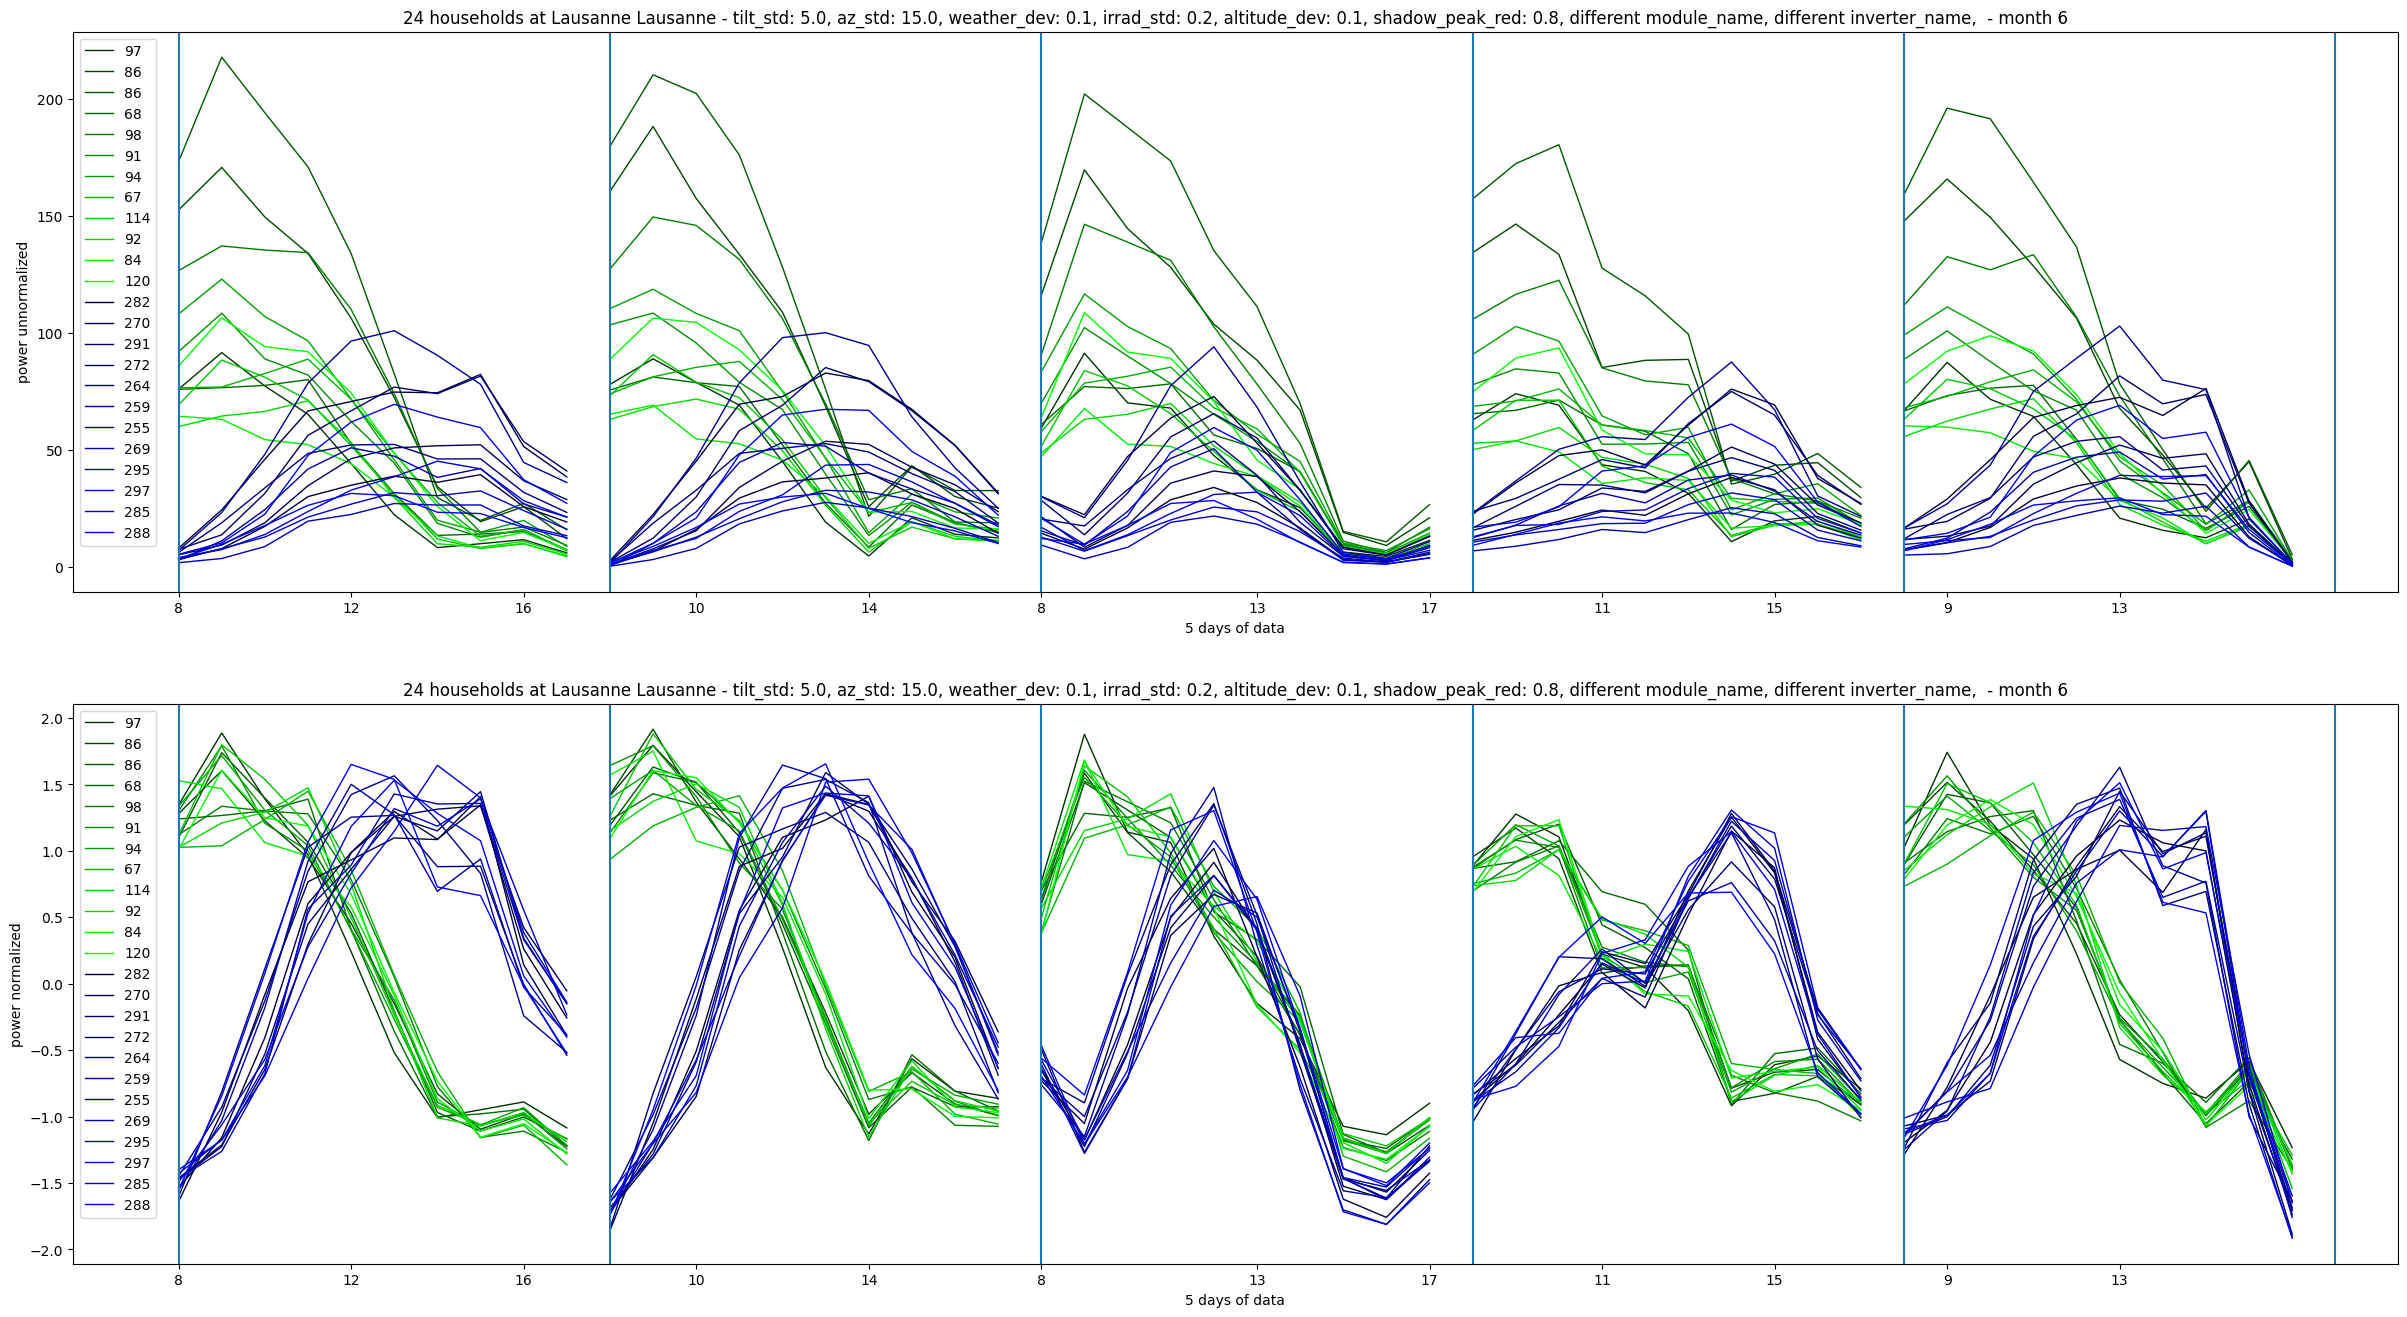

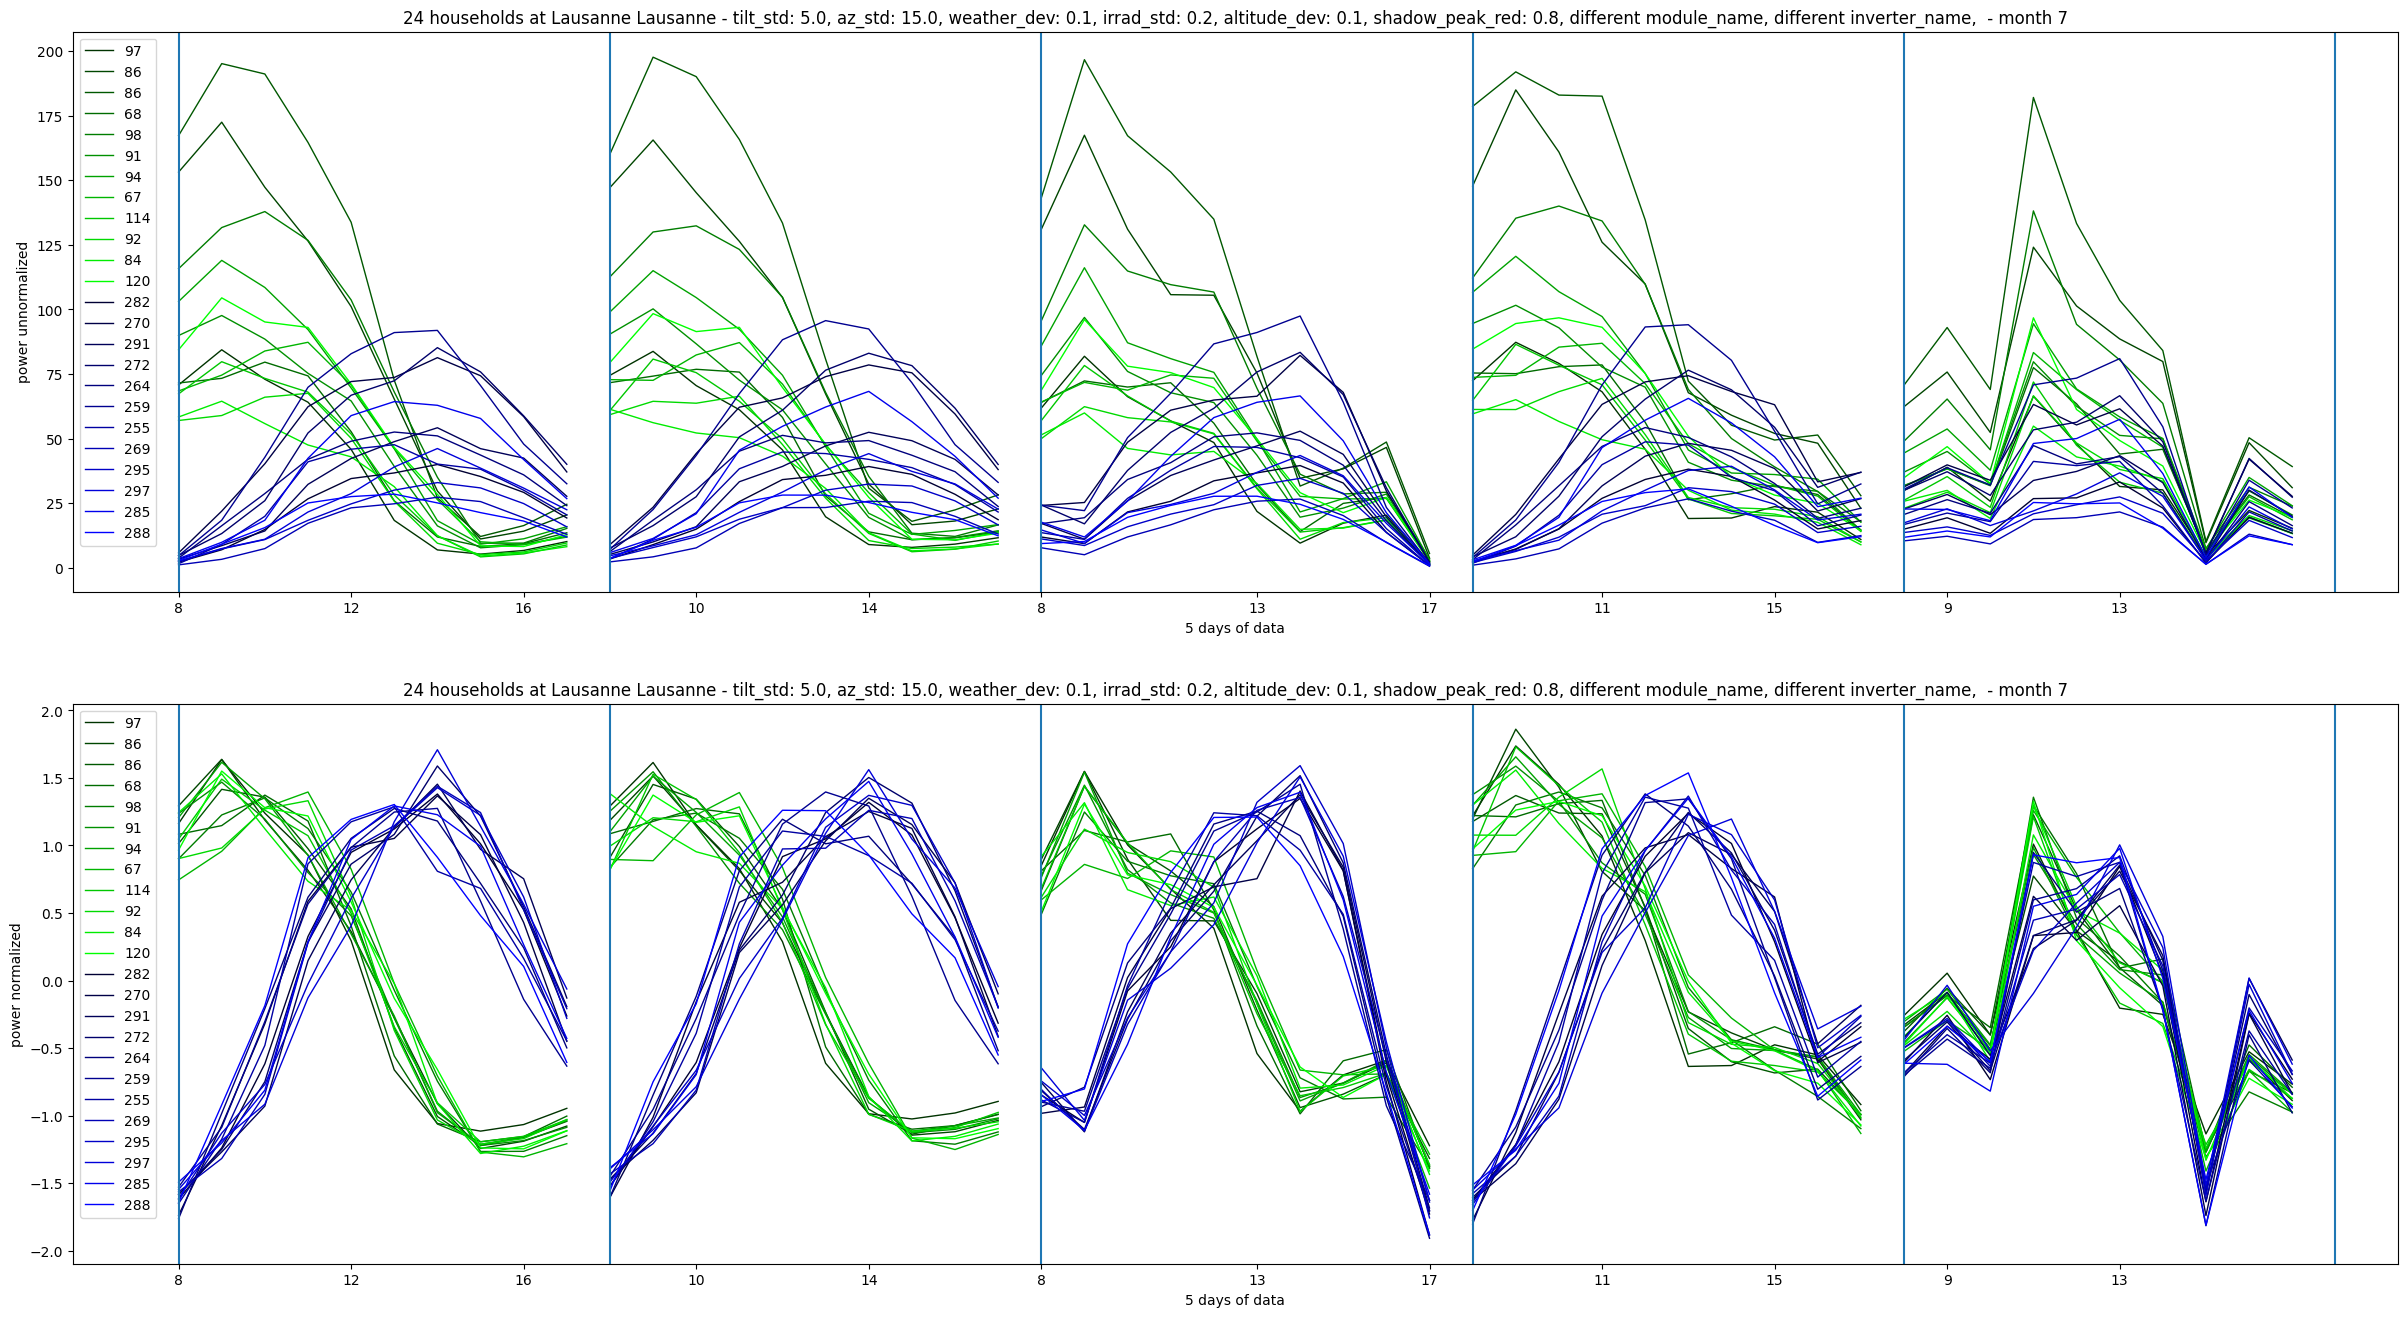

In [2]:
exp_name_new = 'PV_BiModal_NewClients'
exp_name_ptc = 'PV_BiModal'

# ----- SET UP LOGGER -----
filename_env_ptc = config.PVDATA_DIR + '/'+ exp_name_ptc + "_env"
filename_env_new = config.PVDATA_DIR + '/'+ exp_name_ptc +"_new_clients_env"
filename_res_ptc = os.path.join(os.getcwd(), "saved_results", exp_name_ptc)
filename_res_new = os.path.join(os.getcwd(), "saved_results", exp_name_new)

# ------ LOAD META_TRAIN DATA ------
# NOTE: env generated in notebook 1_visualization
file = open(filename_env_ptc, 'rb')
env_dict_ptc = pickle.load(file)
msg = '[INFO] loaded data for {:2.0f} clients'.format(env_dict_ptc['num_clients'])
print(msg)
file.close()
num_clients_ptc = env_dict_ptc['num_clients'] 
print('\n'+env_dict_ptc['info'])

# ------ LOAD META_TEST DATA ------
load_env_new = True
if load_env_new:
    file = open(filename_env_new, 'rb')
    env_dict_new = pickle.load(file)
    msg = '[INFO] loaded data for {:2.0f} clients'.format(env_dict_new['num_clients'])
    print(msg)
    file.close()
    num_clients_new = env_dict_new['num_clients'] 
    print('\n'+env_dict_new['info'])
else:
    from experiments.data_sim import PVDataset
    env_dict_new = {k: copy.deepcopy(env_dict_ptc[k]) for k in (
        'city_names', 'num_modes', 'tilt_std', 'az_std', 'weather_dev', 
        'irrad_std', 'altitude_dev', 'shadow_peak_red', 'train_scenarios',
        'lags', 'months', 'hours', 'use_station_irrad_direct', 
        'use_station_irrad_diffuse', 'delay_irrad', 'remove_constant_cols')
    }

    for key in env_dict_new['train_scenarios'].keys():
        del env_dict_new['train_scenarios'][key]['time_series']
        del env_dict_new['train_scenarios'][key]['clients_data']
        assert list(env_dict_new['train_scenarios'][key].keys()) == ['m_train', 'train_years', 'valid_years']

    # set new properties
    env_dict_new['num_clients'] = 10 # can be changed
    env_dict_new['module_name'] = get_available_modules('sandia')[0:env_dict_new['num_clients']] 
    env_dict_new['inverter_name'] = get_available_inverters('cec')[0:env_dict_new['num_clients']]

    # generate data
    env_dict_new = PVDataset(env_dict_new).generate_clients_data(shuffle=False)

    # remove some non AR features
    feat_remove = [x for x in env_dict_new['feature_names'] if not  x in env_dict_ptc['feature_names']]
    for feature_name in feat_remove:
        remove_feature(
            env_dict=env_dict_new, 
            feature_name=feature_name, in_place=True)

    # save env
    file = open(filename_env_new, 'wb')
    pickle.dump(env_dict_new, file)
    file.close()
    msg = '[INFO] saved data for {:2.0f} clients'.format(env_dict_new['num_clients'])
    print(msg)


for scenario_name in env_dict_new['train_scenarios'].keys():
    print(scenario_name + ' has {:3.0f} train and {:3.0f} validation samples'.format(
        env_dict_new['train_scenarios'][scenario_name]['clients_data'][0][0].shape[0],
        env_dict_new['train_scenarios'][scenario_name]['clients_data'][0][2].shape[0]))
num_features = len(env_dict_new['feature_names'])
print('\n[INFO] {:2.0f} features: '.format(
    len(env_dict_new['feature_names'])), *env_dict_new['feature_names'])

visualize_env(env_dict_new, num_days=5, year=2018, scenario_name='1y')


# Step 1: Mean Model

In [3]:
methods_to_run = [] # 'lingp', 'nn44', 'nn4444', 
verbose=True
criteria = ['rsmse']


In [4]:
# set properties that are different based on the GP mean
options_base={
        # noise setup
        'optimize_noise':True, 
        'noise_std':None, 
        'likelihood_str':'Gaussian',
        # linear model
        'covar_module_str': ['zero'], 'mean_module_str':['linear'],
        'kernel_nn_layers': [], 'mean_nn_layers':[],
        'nonlinearity_output_m': None, 'nonlinearity_output_k': None, 
        'nonlinearity_hidden_m': None, 'nonlinearity_hidden_k': None,
        'feature_dim':2, 
        # Configuration for GP-Prior learning
        'lr': 1e-2,           # learning rate for Adam optimizer'
        'lr_decay': 0.90,     # 'multiplicative learning rate decay factor applied after every 1000 steps'
        'task_batch_size': 5, # 'batch size for meta training, i.e. number of tasks for computing grads'
        'normalize_data': True,
        'optimize_lengthscale':True, 'lengthscale_fix':None,
        # Configuration for SVGD
        'num_iter_fit': 2000,
        'max_iter_fit': 2500,
        'early_stopping': True,
        'num_particles': [1],
        'bandwidth': 1,
        'n_threads': 8,
        'hyper_prior_dict': {'noise_raw_loc':softplus_inverse(0.5), 'noise_raw_scale': 1,}
}


options = {
           'lingp': copy.deepcopy(options_base),
           'nn44': copy.deepcopy(options_base),
           'nn4444': copy.deepcopy(options_base),
           'nn16': copy.deepcopy(options_base),
        }
options['nn44'].update({
                'mean_module_str':['NN'], 'mean_nn_layers':[(4,4)],
                'nonlinearity_hidden_m': torch.tanh,
                })
options['nn4444'].update({
                'mean_module_str':['NN'], 'mean_nn_layers':[(4,4,4,4)],
                'nonlinearity_hidden_m': torch.tanh
                })
options['nn16'].update({
                'mean_module_str':['NN'], 'mean_nn_layers':[(16,16)],
                'nonlinearity_hidden_m': torch.tanh,
                })


pf_scheduler = PriorFactorScheduler(
        method='grid', num=6, space='log', 
        pf_range=(1e-2, 1),
        test_no_regul=True, init_step_size=None, 
        early_stopping=True, thresh=0.05,
        check_of_any=False # enough not to over-fit on average
        )


# ---------- TRAIN ----------
for method_to_run in methods_to_run:
    train_models(
            exp_name=exp_name_new, method_to_run=method_to_run, mode='personal',
            env_dict=env_dict_new, random_seed=random_seed, criteria=criteria,
            options=options, pf_scheduler=pf_scheduler, verbose=True, 
            save_models=True, 
            clients_subset=None,
            train_scenarios=['sml', '1y'],
            #initial_particles = {'noise_raw': softplus_inverse(0.1)}
            )
# personal models
print('\n\n----- loading individual house models -----')
models_indiv_new, results_indiv_new = load_trained_models(
    mode='personal', clients_subset=np.arange(env_dict_new['num_clients']),
    filename_res=os.path.join(filename_res_new, 'personal'))




----- loading individual house models -----


TypeError: load_trained_models() missing 1 required positional argument: 'ts_data'

# Residual of new clients from shared trained model

In [ ]:
from utils.search_models import _eval

method_mean_ptc = 'nn32'
method_resd_ptc = 'nn44fixl_optnoise'
scen_ptc = '1y'
criterion_ptc = 'rsmse'

# shared nn models
print('\n\n----- loading shared (shared nn) models -----')
models_shared_nn_ptc, results_shared_nn_ptc = load_trained_models(
    mode='ours', methods=[method_mean_ptc],
    filename_res=os.path.join(filename_res_ptc, 'global_' + scen_ptc))   

model_base = models_shared_nn_ptc[method_mean_ptc][scen_ptc][criterion_ptc]
if model_base == None:
    print('[ERROR] first run the base method.')
    raise NotImplementedError
  
# calculate performance of trained shared nn on new clients
results_shared_nn_new = {method_mean_ptc: dict.fromkeys(env_dict_new['train_scenarios'].keys())}
# calculate residuals  
env_dict_res_new = copy.deepcopy(env_dict_new)

for scenario in env_dict_new['train_scenarios'].keys():
    print('\nTraining scenario: ', scenario)
    results_shared_nn_new[method_mean_ptc][scenario] = {
        'rmse':{
            'criterion_train':np.zeros(num_clients_new),
            'criterion_valid':np.zeros(num_clients_new)}, 
        'rsmse':{
            'criterion_train':np.zeros(num_clients_new),
            'criterion_valid':np.zeros(num_clients_new)}}

    del env_dict_res_new['train_scenarios'][scenario]['time_series']
    res_train_std, res_valid_std = np.zeros(num_clients_new), np.zeros(num_clients_new)
    res_train_mean, res_valid_mean = np.zeros(num_clients_new), np.zeros(num_clients_new)
    for client_num in np.arange(num_clients_new):
        x_train, y_train, x_valid, y_valid = env_dict_new['train_scenarios'][scenario]['clients_data'][client_num]
        x_train, y_train = _handle_input_dimensionality(x_train, y_train)
        x_valid, y_valid = _handle_input_dimensionality(x_valid, y_valid)
        
        # residual of train
        y_train_pred, _ = model_base.predict_only_mean(x_train, y_train, x_train)
        y_valid_pred, _ = model_base.predict_only_mean(x_train, y_train, x_valid)
        y_train_pred = y_train_pred.reshape(y_train.shape)
        y_valid_pred = y_valid_pred.reshape(y_valid.shape)
        data_tup = (x_train, 
                    y_train-y_train_pred,
                    x_valid,
                    y_valid-y_valid_pred)

        env_dict_res_new['train_scenarios'][scenario]['clients_data'][client_num] = data_tup
        
        results_shared_nn_new[method_mean_ptc][scenario]['rmse']['criterion_valid'][client_num] = \
            np.sqrt(np.mean((y_valid-y_valid_pred)**2))
        results_shared_nn_new[method_mean_ptc][scenario]['rmse']['criterion_train'][client_num] = \
            np.sqrt(np.mean((y_train-y_train_pred)**2))

        results_shared_nn_new[method_mean_ptc][scenario]['rsmse']['criterion_valid'][client_num] = \
            np.sqrt(np.mean((y_valid-y_valid_pred)**2))/np.std(y_valid)
        results_shared_nn_new[method_mean_ptc][scenario]['rsmse']['criterion_train'][client_num] = \
            np.sqrt(np.mean((y_train-y_train_pred)**2))/np.std(y_train)
            




----- loading shared (shared nn) models -----

[INFO] results of method nn4444 loaded.

Training scenario:  sml

Training scenario:  1y

Training scenario:  5y

Training scenario:  14y


In [ ]:
# ---------- Load Trained Residuals Models ----------
print('----- loading residuals models -----')
models_ours_ptc, results_ours_ptc = load_trained_models(
    mode='ours', methods=[method_mean_ptc+'_'+method_resd_ptc],
    filename_res=os.path.join(filename_res_ptc, 'ours_' + scen_ptc))


model_base = models_shared_nn_ptc[method_mean_ptc][scen_ptc][criterion_ptc]
if model_base == None:
    print('[ERROR] first run the base method.')
    raise NotImplementedError
  
# calculate performance of trained shared nn on new clients
method_ours = method_mean_ptc+'_'+method_resd_ptc
results_ours_new = {method_ours: dict.fromkeys(env_dict_new['train_scenarios'].keys())}
model = models_ours_ptc['nn4444_nn44fixl_optnoise']['1y']['rsmse']

for scenario in env_dict_res_new['train_scenarios'].keys():
    print('\nTraining scenario: ', scenario)
    results_ours_new[method_ours][scenario] = {
        'rmse':{
            'criterion_train':np.zeros(num_clients_new),
            'criterion_valid':np.zeros(num_clients_new)}, 
        'rsmse':{
            'criterion_train':np.zeros(num_clients_new),
            'criterion_valid':np.zeros(num_clients_new)}}

    for client_num in np.arange(num_clients_new):
        x_train, y_train, x_valid, y_valid = env_dict_res_new['train_scenarios'][scenario]['clients_data'][client_num]
        x_train, y_train = _handle_input_dimensionality(x_train, y_train)
        x_valid, y_valid = _handle_input_dimensionality(x_valid, y_valid)
        
        # predict
        y_train_pred, _ = model.predict(x_train, y_train, x_train)
        y_valid_pred, _ = model.predict(x_train, y_train, x_valid)
        y_train_pred = y_train_pred.reshape(y_train.shape)
        y_valid_pred = y_valid_pred.reshape(y_valid.shape)
        
        results_ours_new[method_ours][scenario]['rmse']['criterion_valid'][client_num] = \
            np.sqrt(np.mean((y_valid-y_valid_pred)**2))
        results_ours_new[method_ours][scenario]['rmse']['criterion_train'][client_num] = \
            np.sqrt(np.mean((y_train-y_train_pred)**2))

        results_ours_new[method_ours][scenario]['rsmse']['criterion_valid'][client_num] = \
            np.sqrt(np.mean((y_valid-y_valid_pred)**2))/np.std(y_valid)
        results_ours_new[method_ours][scenario]['rsmse']['criterion_train'][client_num] = \
            np.sqrt(np.mean((y_train-y_train_pred)**2))/np.std(y_train)
           

----- loading residuals models -----

[INFO] results of method nn4444_nn44fixl_optnoise loaded.

Training scenario:  sml

Training scenario:  1y

Training scenario:  5y

Training scenario:  14y


In [ ]:
results_ours_comb_new = copy.deepcopy(results_ours_new)
for met in results_ours_new.keys():
    if results_ours_new[met] is None:
        continue
    # set rsmse
    for train_scenario in results_ours_comb_new[met].keys():
        for valid_or_train in results_ours_new[met][train_scenario]['rsmse'].keys():
            if valid_or_train.startswith('criterion'):
                arr1 = np.array(results_ours_new[met][train_scenario]['rsmse'][valid_or_train])
                arr2 = np.array(results_shared_nn_new[met.split('_')[0]][train_scenario]['rsmse'][valid_or_train])
                results_ours_comb_new[met][train_scenario]['rsmse'][valid_or_train] = arr1 * arr2
        # TODO: how to combine other metrics?


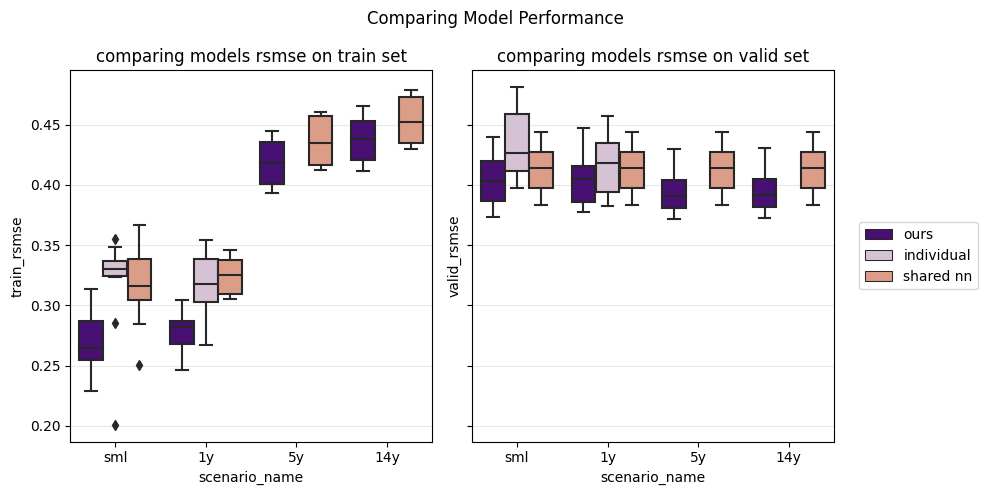

,method,scenario_name,valid_rsmse_mean,valid_rsmse_min,valid_rsmse_max,valid_rsmse_median
0,individual,1y,0.416574,0.382732,0.457383,0.418181
1,individual,sml,0.433456,0.397768,0.481015,0.426761
2,ours,14y,0.395467,0.372333,0.430200,0.391549
3,ours,1y,0.405709,0.377609,0.446967,0.404526
4,ours,5y,0.394780,0.371894,0.429756,0.390917
5,ours,sml,0.404753,0.373066,0.439296,0.402885
6,shared nn,14y,0.413533,0.383587,0.443437,0.413844
7,shared nn,1y,0.413533,0.383587,0.443437,0.413844
8,shared nn,5y,0.413533,0.383587,0.443437,0.413844
9,shared nn,sml,0.413533,0.383587,0.443437,0.413844


In [ ]:
results_mix = {
    'ours':results_ours_comb_new[method_ours], 
    'individual':results_indiv_new['nn16'],
    'shared nn':results_shared_nn_new['nn4444']}

perf_box_plots(
    env_dict_res_new, criterion='rsmse', methods=results_mix.keys(), 
    results_all=results_mix, plot_title= 'Comparing Model Performance')


# Generate Augmented Dataset
Unimodal with more houses: the first 24 are the same as before, add another 48.

[INFO] loaded data for 72 clients

72 households at Lausanne - tilt_std: 5.0, az_std: 15.0, weather_dev: 0.1, irrad_std: 0.2, altitude_dev: 0.1, shadow_peak_red: 0.8, different module_name, different inverter_name, 
sml has 150 train and 610 validation samples
1y has 610 train and 610 validation samples
5y has 3050 train and 610 validation samples
14y has 8540 train and 610 validation samples

[INFO] 15 features:  H_sun T2m WS10m station_irrad_direct_prev lag 1 lag 2 lag 4 lag 18 lag 20 lag 22 lag 43 lag 70 lag 74 lag 121 lag 145


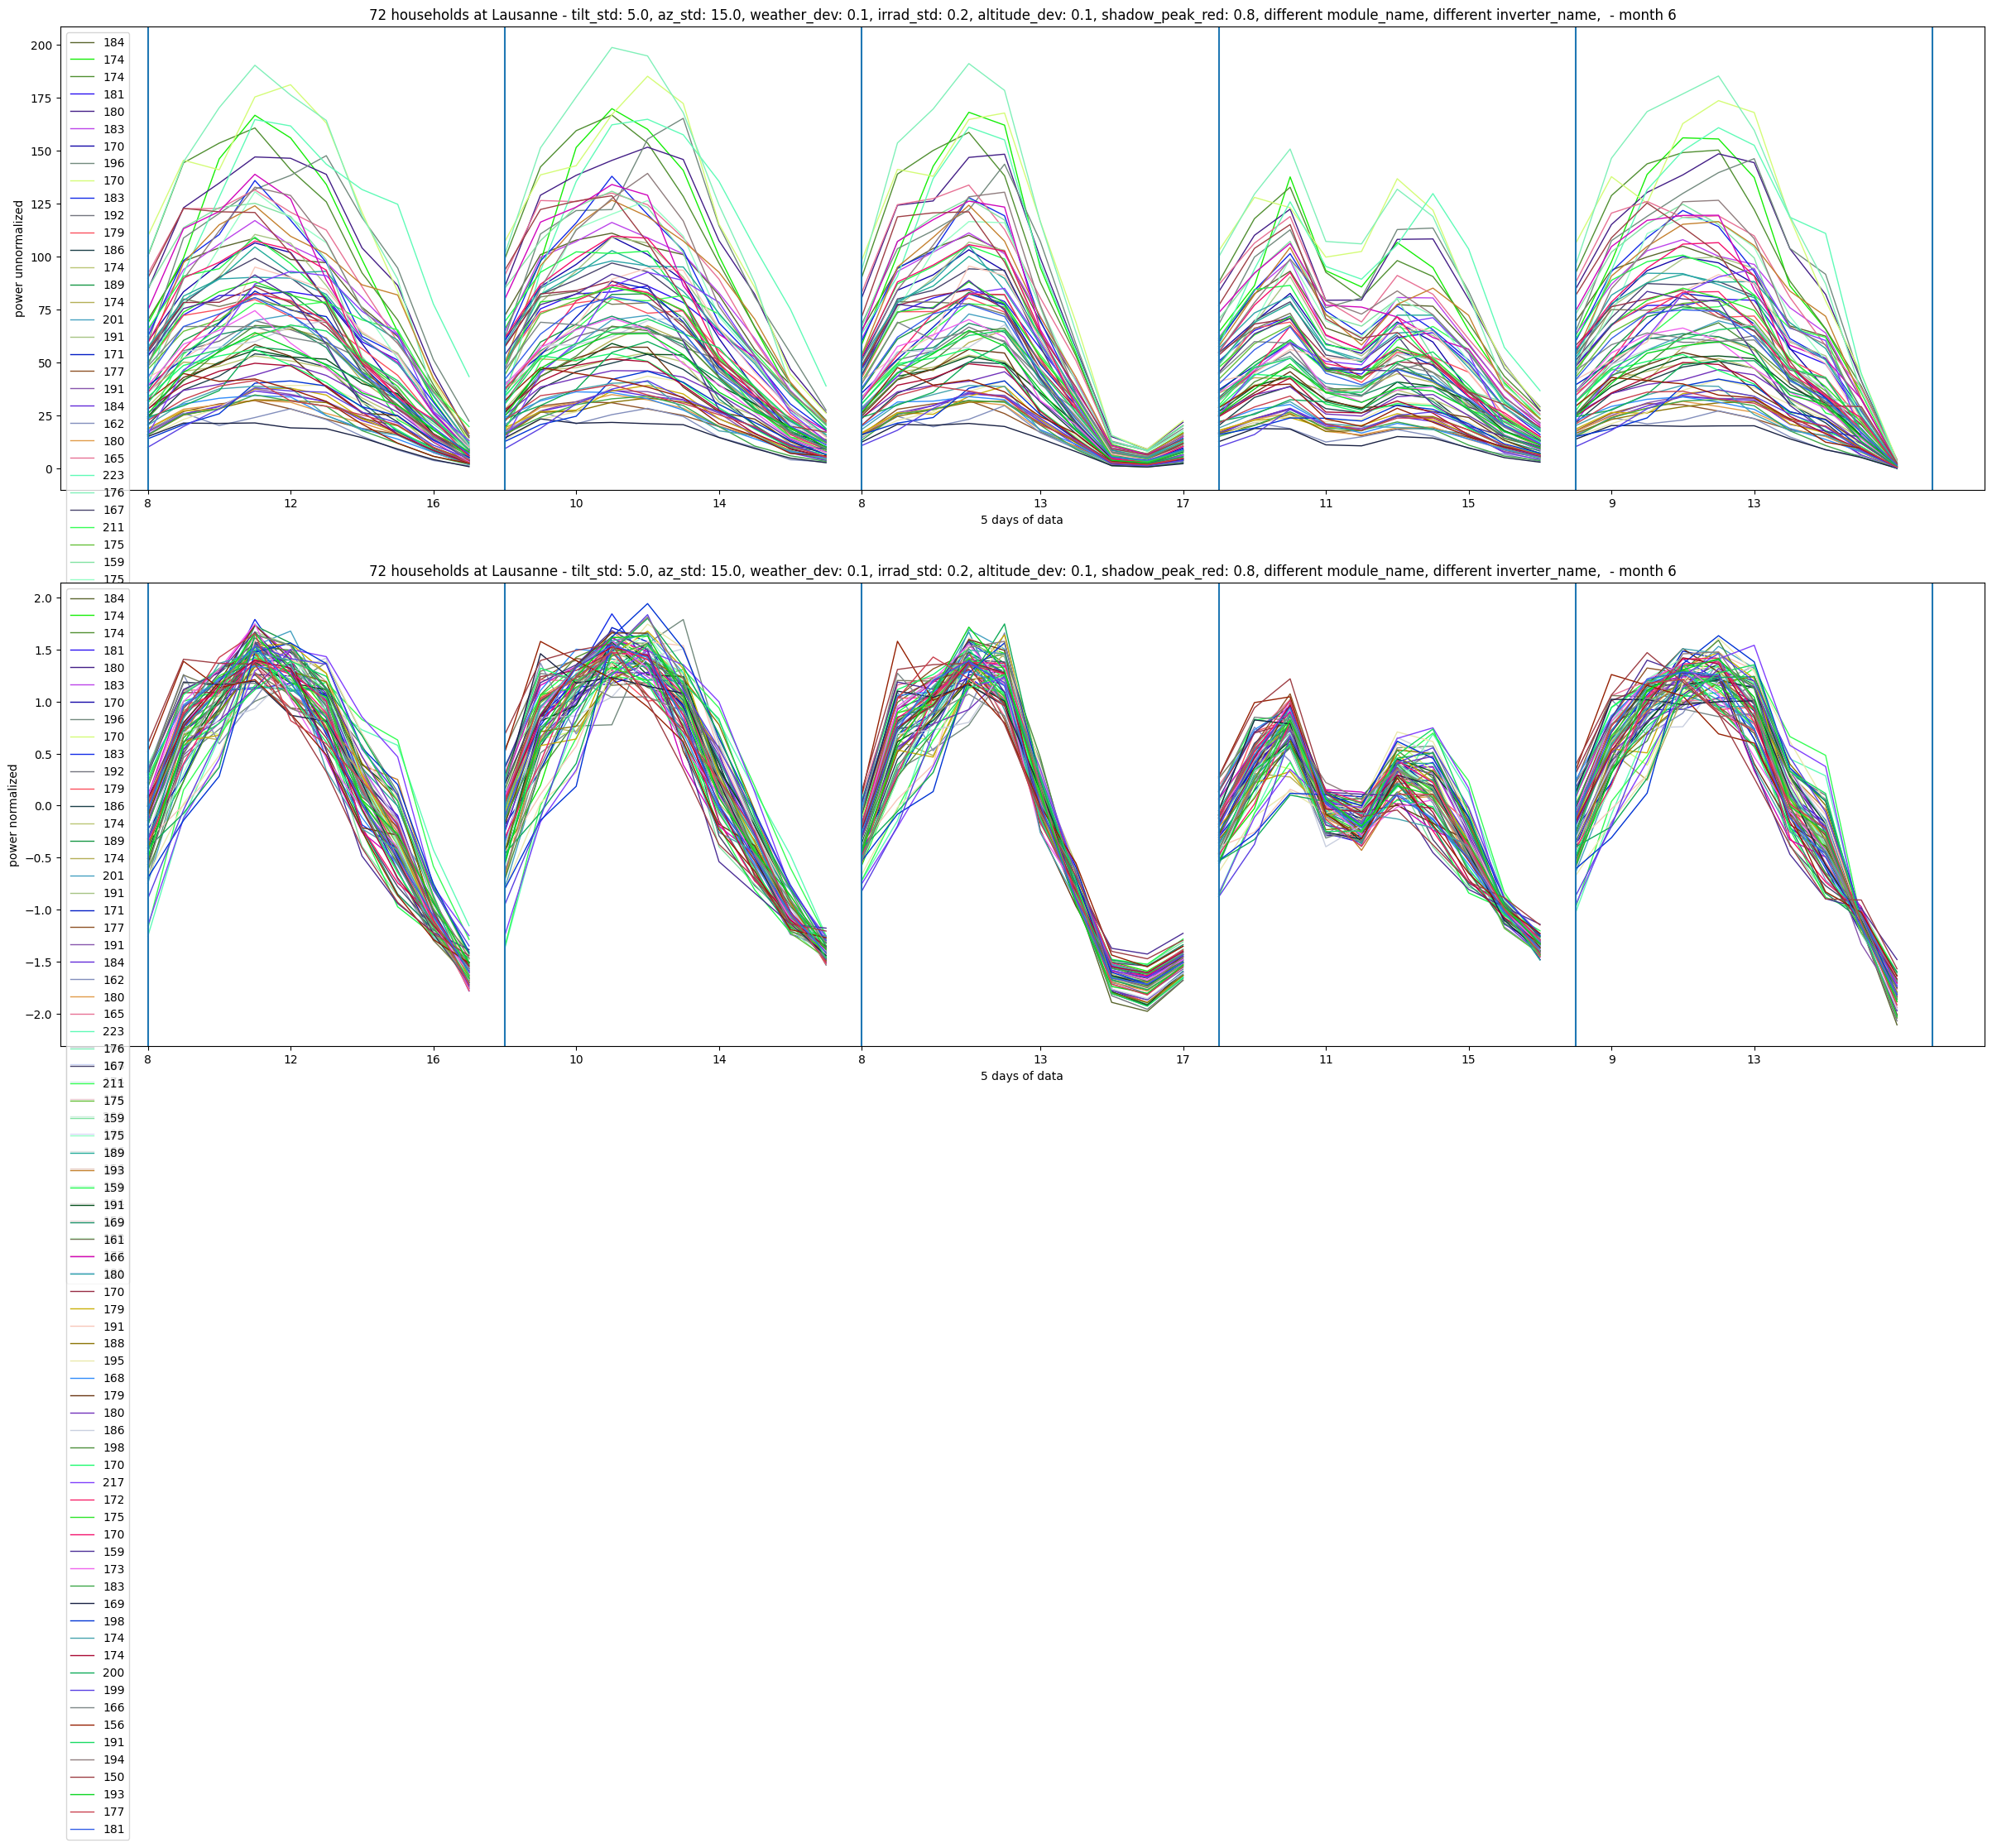

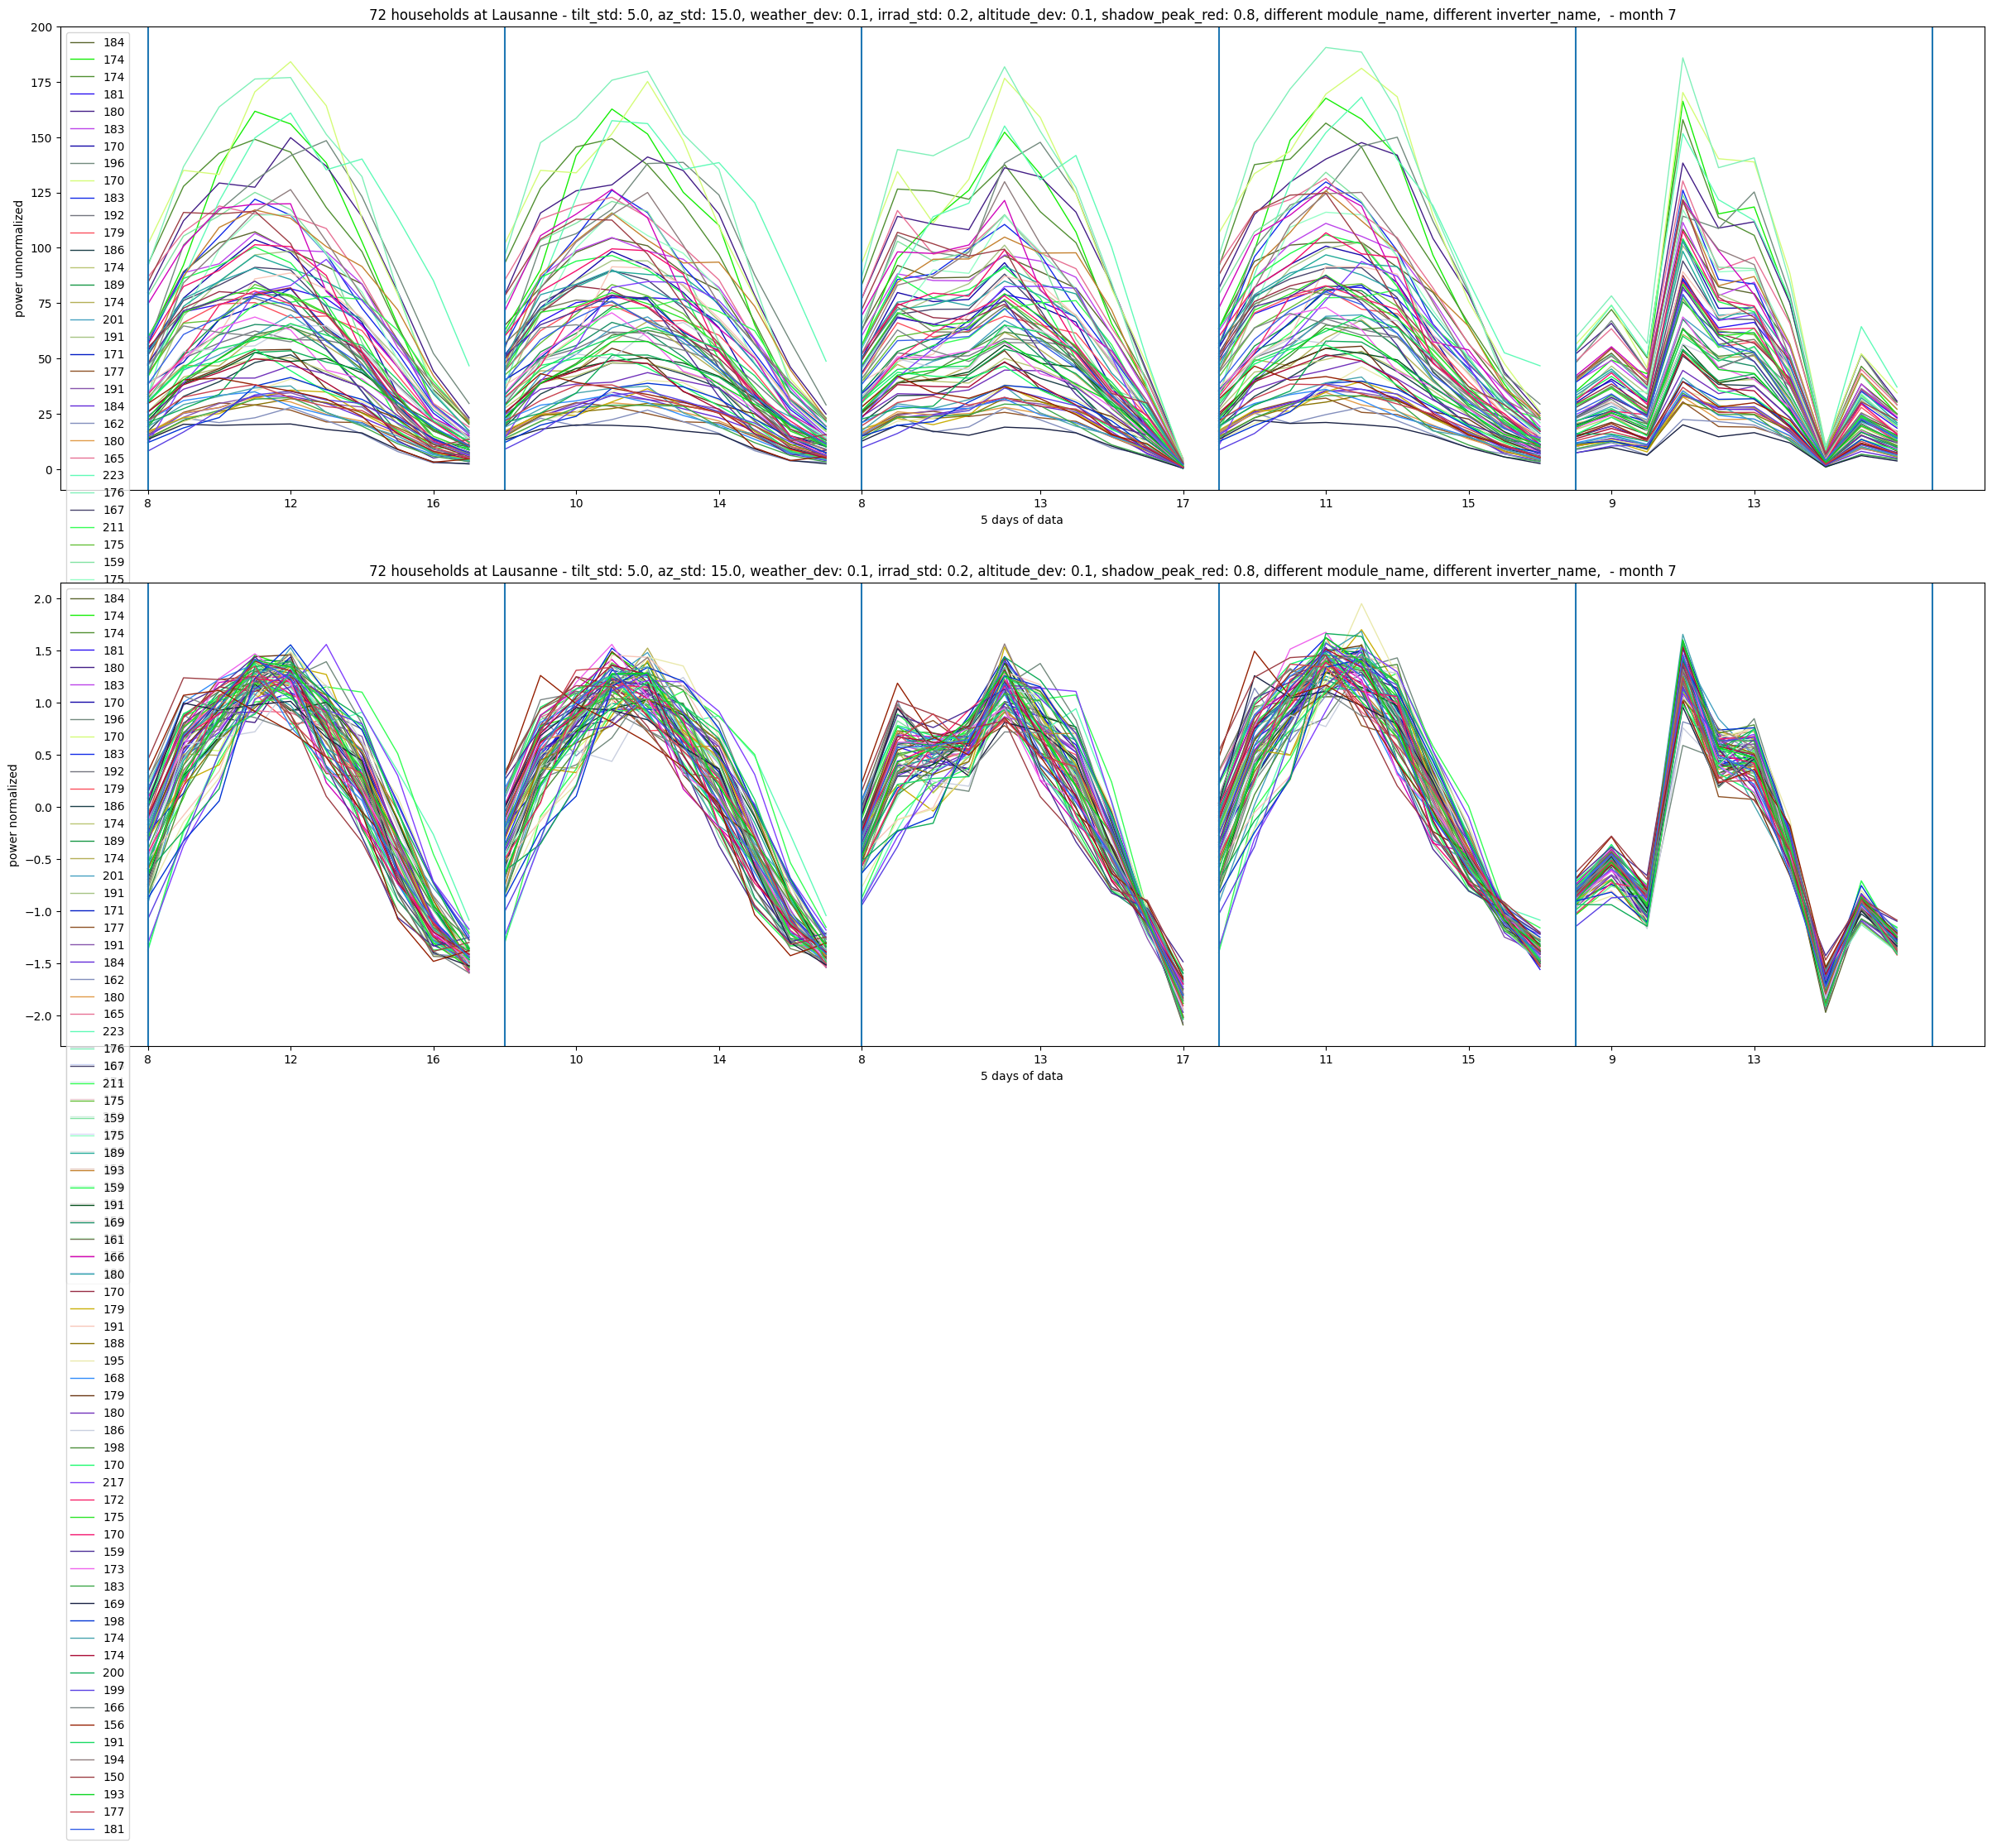

In [ ]:
exp_name_aug = 'PV_UniModal_AugmentedClients'
exp_name_ptc = 'PV_UniModal'

# ----- SET UP LOGGER -----
filename_env_ptc = config.PVDATA_DIR + '/'+ exp_name_ptc + "_env"
filename_env_aug = config.PVDATA_DIR + '/'+ exp_name_aug +"_env"
filename_res_ptc = os.path.join(os.getcwd(), "saved_results", exp_name_ptc)
filename_res_aug = os.path.join(os.getcwd(), "saved_results", exp_name_aug)


# ------ LOAD META_TEST DATA ------
load_env_aug = True
if load_env_aug:
    file = open(filename_env_aug, 'rb')
    env_dict_aug = pickle.load(file)
    msg = '[INFO] loaded data for {:2.0f} clients'.format(env_dict_aug['num_clients'])
    print(msg)
    file.close()
    print('\n'+env_dict_aug['info'])
else:
    from experiments.data_sim import PVDataset
    # ------ LOAD META_TRAIN DATA ------
    # NOTE: env generated in notebook 1_visualization
    file = open(filename_env_ptc, 'rb')
    env_dict_ptc = pickle.load(file)
    msg = '[INFO] loaded data for {:2.0f} clients'.format(env_dict_ptc['num_clients'])
    print(msg)
    file.close()
    num_clients_ptc = env_dict_ptc['num_clients'] 
    print('\n'+env_dict_ptc['info'])

    env_dict_new = {k: copy.deepcopy(env_dict_ptc[k]) for k in (
        'city_names', 'num_modes', 'tilt_std', 'az_std', 'weather_dev', 
        'irrad_std', 'altitude_dev', 'shadow_peak_red', 'train_scenarios',
        'lags', 'months', 'hours', 'use_station_irrad_direct', 
        'use_station_irrad_diffuse', 'delay_irrad', 'remove_constant_cols')
    }

    for key in env_dict_new['train_scenarios'].keys():
        del env_dict_new['train_scenarios'][key]['time_series']
        del env_dict_new['train_scenarios'][key]['clients_data']
        assert list(env_dict_new['train_scenarios'][key].keys()) == ['m_train', 'train_years', 'valid_years']

    # set new properties
    env_dict_new['num_clients'] = 48 # can be changed
    env_dict_new['module_name'] = get_available_modules('sandia')[0:env_dict_new['num_clients']] 
    env_dict_new['inverter_name'] = get_available_inverters('cec')[0:env_dict_new['num_clients']]

    # generate data
    env_dict_new = PVDataset(env_dict_new).generate_clients_data(shuffle=False)

    # remove some non AR features
    feat_remove = [x for x in env_dict_new['feature_names'] if not  x in env_dict_ptc['feature_names']]
    for feature_name in feat_remove:
        remove_feature(
            env_dict=env_dict_new, 
            feature_name=feature_name, in_place=True)

    # augment participating and new
    env_dict_aug = copy.deepcopy(env_dict_ptc)
    for key in ['num_clients', 'module_name', 'inverter_name']:
        env_dict_aug[key] = env_dict_ptc[key] + env_dict_new[key]
    # update number of clients per mode
    for mode_num in np.arange(len(env_dict_ptc['num_clients_per_mode'])):
        env_dict_aug['num_clients_per_mode'][mode_num] = env_dict_ptc['num_clients_per_mode'][mode_num] + env_dict_new['num_clients_per_mode'][mode_num]
    # update info    
    env_dict_aug['info'] = str(env_dict_aug['num_clients']) + env_dict_ptc['info'][2:] 
    # update config
    for key in env_dict_ptc['clients_config'].keys():
        if len(env_dict_ptc['clients_config'][key]) == env_dict_ptc['num_clients']:
            env_dict_aug['clients_config'][key] = env_dict_ptc['clients_config'][key] + env_dict_new['clients_config'][key]
    # update data
    for train_scenario in env_dict_aug['train_scenarios'].keys():
        for key in ['time_series', 'clients_data']:
            env_dict_aug['train_scenarios'][train_scenario][key] = \
                env_dict_ptc['train_scenarios'][train_scenario][key] + \
                env_dict_new['train_scenarios'][train_scenario][key]

    # save env
    file = open(filename_env_aug, 'wb')
    pickle.dump(env_dict_aug, file)
    file.close()
    msg = '[INFO] saved data for {:2.0f} clients'.format(env_dict_aug['num_clients'])
    print(msg)


for scenario_name in env_dict_aug['train_scenarios'].keys():
    print(scenario_name + ' has {:3.0f} train and {:3.0f} validation samples'.format(
        env_dict_aug['train_scenarios'][scenario_name]['clients_data'][0][0].shape[0],
        env_dict_aug['train_scenarios'][scenario_name]['clients_data'][0][2].shape[0]))
num_features = len(env_dict_aug['feature_names'])
print('\n[INFO] {:2.0f} features: '.format(
    len(env_dict_aug['feature_names'])), *env_dict_aug['feature_names'])

visualize_env(env_dict_aug, num_days=5, year=2018, scenario_name='1y')
